In [19]:
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt0
import seaborn as sns
import tntorch as tn
sys.path.append('../../')

from matplotlib.ticker import LinearLocator
from src.ttts import TTTS

from robot_utils import PlanarManipulator, PlanarManipulatorCost, Point2PointMotion

%matplotlib inline
%load_ext autoreload

%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'cuda'

In [20]:
# Define the robot
n_joints = 3
link_lengths = torch.tensor([1./n_joints]*n_joints).to(device)
max_theta = torch.pi
min_theta = -1*max_theta
n_kp = 10;
T = 1;
dt = 0.01;

num_steps = int(T/dt);

d0_x = 20; d0_theta = 20; d0_w = 20;
# Define the environment and the task (Cost function)
x_obst = [torch.tensor([-0.3,-0.]).to(device), torch.tensor([-0.3,0.5]).to(device)]#,torch.tensor([0.5,0.])]
r_obst = [0.175]*2

margin=0.02
w_goal= 1; w_obst=1; w_ee=0.; w_control=1;
b_goal=0.25;b_obst=1; b_ee=10; b_control=1.;

theta_0 = torch.zeros(n_joints).to(device).view(1,-1)
theta_0[:,:2] = torch.tensor([2.1*torch.pi/4,-1.5*torch.pi/4]).to(device).view(1,-1)
theta_3 = 1*theta_0

# xy_goal = torch.tensor([-0.5,0.2]).to(device).view(1,-1)

K = 3 # Number of basis functions

robot = PlanarManipulator(n_joints=n_joints,link_lengths=link_lengths,max_theta=max_theta,n_kp=n_kp, device=device)
bounds = [robot.min_config, robot.max_config]
p2p_motion = Point2PointMotion(T=T, n=n_joints,dt=dt,K=K,basis='bs',bounds=bounds, device=device)
costPlanarManipulator = PlanarManipulatorCost(robot,p2p_motion=p2p_motion,x_obst=x_obst,r_obst=r_obst, margin=margin,
                                              w_goal=w_goal,w_obst=w_obst,w_ee=w_ee, w_control=w_control,
                                              b_goal=b_goal, b_obst=b_obst,b_ee=b_ee, b_control=b_control, device=device)

In [21]:
# Pick and place location (via-points: x_1 and x_2)
x_min_place = -0.75; x_max_place = -0.5;
y_min_place = -0.5; y_max_place = 0.5;

x_min_pick =  0.5; x_max_pick = 0.75;
y_min_pick = -0.5; y_max_pick = 0.5;

d0_y = int(d0_x/2);
domain_x1 = [torch.linspace(x_min_pick,x_max_pick,d0_x).to(device),
            torch.linspace(y_min_pick,y_max_pick,d0_y).to(device)]
domain_x2= [torch.linspace(x_min_place,x_max_place,d0_x).to(device),
            torch.linspace(y_min_place,y_max_place,d0_y).to(device)]

domain_theta = [torch.linspace(min_theta, max_theta,d0_theta).to(device)]*(n_joints)

domain_w_theta = [torch.linspace(min_theta, max_theta,d0_theta).to(device)]*(K*n_joints)


domain = domain_theta + domain_w_theta


In [22]:
# generate test set
ns = 1
test_task = torch.zeros(ns,len(domain_x2)).to(device)
for i in range(len(domain_x2)):
    unif = torch.distributions.uniform.Uniform(low=domain_x2[i][0],high=domain_x2[i][-1])
    test_task[:,i]= torch.tensor([unif.sample() for i in range(ns)]).to(device)

test_task = torch.tensor([[-0.6436,  0.50]], device='cuda:0')

In [ ]:
def objective_func(x):
    d_goal = costPlanarManipulator.cost_goal(test_task, x)#costPlanarManipulator.cost_ik(x)[:,1]

    # x: (theta_1, w)
    d_control = costPlanarManipulator.cost_control(x,theta_0)#costPlanarManipulator.cost_ik(x)[:,1]

    d_obst = costPlanarManipulator.cost_obst(x,theta_0)#costPlanarManipulator.cost_ik(x)[:,1]

    d_total = 50*d_goal + 1*d_obst + 1*d_control 
    return 1*torch.exp(-(d_total))


In [24]:
import os
model_folder = os.getcwd()+ "/tt_models/"
file_name = model_folder+'manipulator_3D'

ttts = TTTS(func = objective_func, domain = domain, value_k=10, file_name=file_name,
            visit_k=10, warm_start=True, verbose=True, save_tt=True, cross_max_iter=2)


The initial tt model is loaded!


In [25]:
ttts.func = objective_func
ttts.verbose = False
sol = ttts.iterate(max_iters = 5, param_C=3) # K x n

mcts-iters: 1, top-k values: [0.02730654594484101, 0.026735942124919393, 0.0263078778865454, 0.02612819058092585, 0.025798869399291855, 0.025602073689937273, 0.02517565862734685, 0.025089470722758106, 0.02505904929134334, 0.02465867863740636]
mcts-iters: 2, top-k values: [0.03283298454773728, 0.029810041423759356, 0.02782499099902976, 0.02730654594484101, 0.027032971817731694, 0.026745521846826145, 0.026735942124919393, 0.026501803295324308, 0.0263078778865454, 0.026259959560716514]
mcts-iters: 3, top-k values: [0.03283298454773728, 0.029810041423759356, 0.02782499099902976, 0.02730654594484101, 0.027032971817731694, 0.026745521846826145, 0.026735942124919393, 0.026501803295324308, 0.0263078778865454, 0.026259959560716514]
mcts-iters: 4, top-k values: [0.03283298454773728, 0.029810041423759356, 0.02782499099902976, 0.02730654594484101, 0.027032971817731694, 0.026745521846826145, 0.026735942124919393, 0.026501803295324308, 0.0263078778865454, 0.026259959560716514]
mcts-iters: 5, top-k v

In [26]:
### save sol
# torch.save(sol, 'example_reaching_sol.pth')

In [27]:
def plot_traj(opti_x, animation=False, save_as=None):
    batch_size = opti_x.shape[0]
    # x_goal_1 = best_x[0,:2] # desired position of ee at via point
    # theta_1 = best_x[:,2:2+n_joints] # via configuration
    # w = best_x[:,2+n_joints:] # weights of the basis function
    # w01 = w[:,:int(w.shape[-1])] # weights for the first part of the motion: theta_0 to theta_1 
    # theta_t_01 = p2p_motion.gen_traj(theta_0.view(1,-1).repeat(batch_size,1),w01)#batchxtimexjoint_angle
    theta_t_01 = opti_x
    
    theta_t_01 = p2p_motion.smooth_traj(theta_t_01, theta_0) #batchxtimexjoint_angle

    T01 = theta_t_01.shape[1]
    kp_loc_t_01, joint_loc_t_01, ee_loc_t_01,_ = robot.forward_kin(theta_t_01.view(-1,n_joints))

    joint_loc_tt = joint_loc_t_01.view(batch_size,T01,*joint_loc_t_01.shape[1:]).cpu()

    # joint_loc_opt = joint_loc_t_01.view(batch_size,T01,*joint_loc_t_01.shape[1:])[1].cpu()

    x_target = [test_task.view(-1).cpu().numpy()]

    x_obst_np = [x.cpu().numpy() for x in x_obst]
    link_lengths_np = link_lengths.cpu().numpy()
    rect_patch = [[x_min_pick,y_min_pick, x_max_pick-x_min_pick,  y_max_pick-y_min_pick],
                [x_min_place,y_min_place, x_max_place-x_min_place,  y_max_place-y_min_place]]
    
    if animation:
        plt=robot.plot_chain_animation(joint_loc_list=joint_loc_tt, link_lengths=link_lengths_np, x_obst=x_obst_np,
                r_obst=r_obst, rect_patch=rect_patch, x_target=x_target, 
                batch=True, figsize=15, skip_frame=2, title=None, save_as=save_as, 
                color_intensity=0.9, motion=True, alpha=0.8, animation=animation,
                contrast=0.4, idx_highlight=[int(joint_loc_tt.shape[0]-1)], lw=3)
    else:
        plt=robot.plot_chain_batch(joint_loc_list=joint_loc_tt, link_lengths=link_lengths_np, x_obst=x_obst_np,
                r_obst=r_obst, rect_patch=rect_patch, x_target=x_target, 
                batch=True, figsize=15, skip_frame=2, title=None, save_as=save_as, 
                color_intensity=0.9, motion=True, alpha=0.8, animation=animation,
                contrast=0.4, idx_highlight=[int(joint_loc_tt.shape[0]-1)], lw=3)

In [29]:
theta_t = costPlanarManipulator.get_traj(sol, theta_0) #batch x time x joint_angle

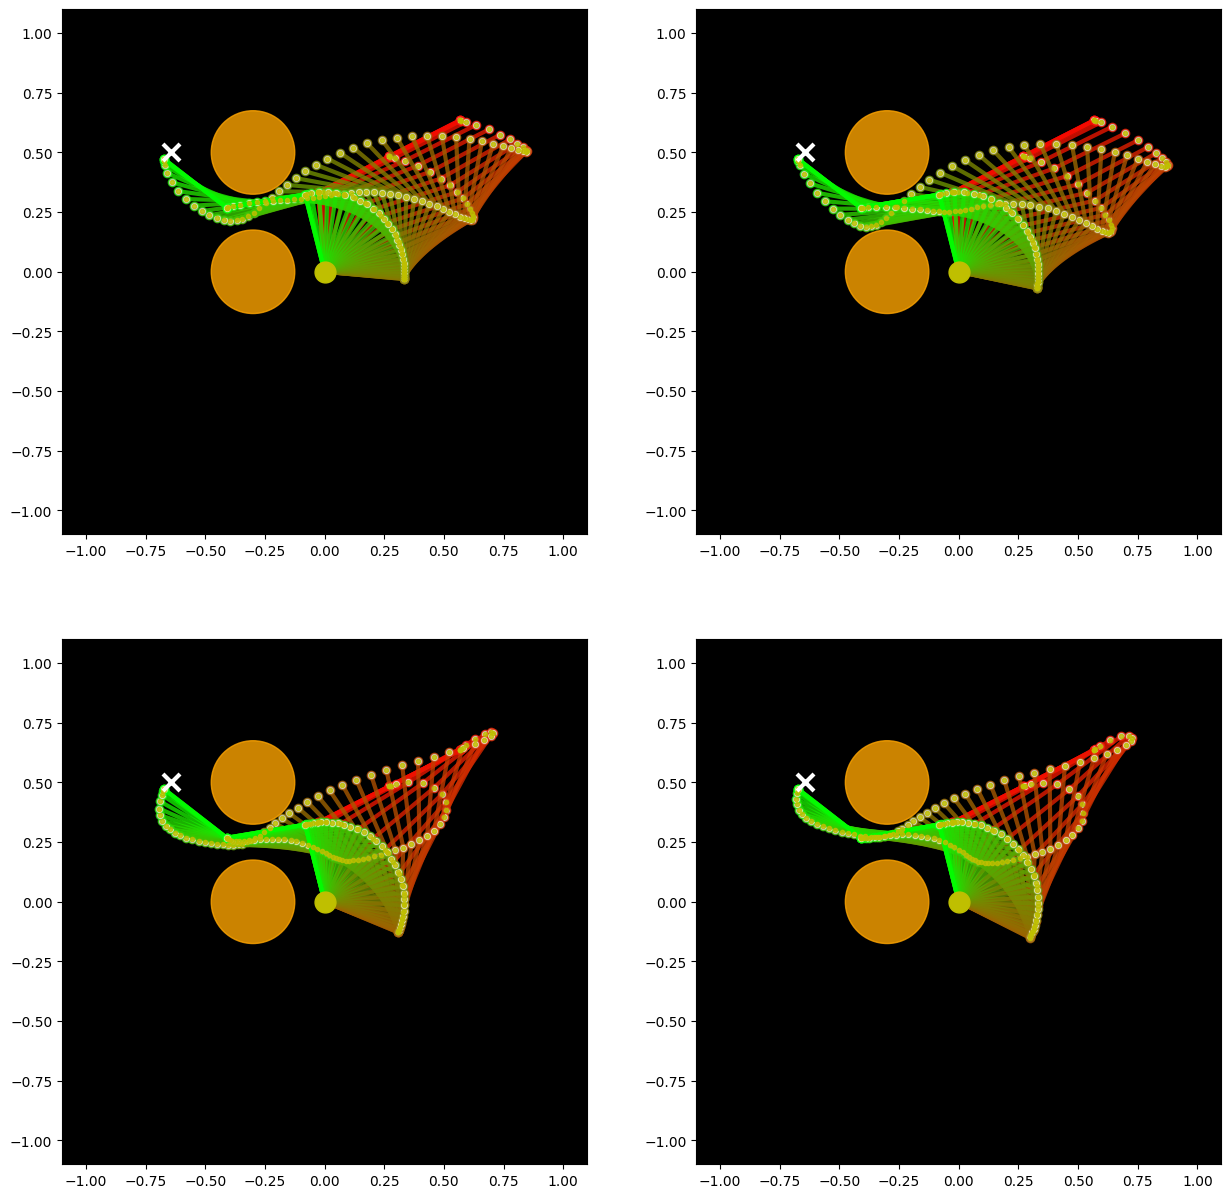

In [32]:
plot_traj(theta_t)

### CMA-ES

In [43]:
def objective_func2(x):
    d_goal = costPlanarManipulator.cost_goal(test_task, x)#costPlanarManipulator.cost_ik(x)[:,1]

    # x: (theta_1, w)
    d_control = costPlanarManipulator.cost_control(x,theta_0)#costPlanarManipulator.cost_ik(x)[:,1]

    d_obst = costPlanarManipulator.cost_obst(x,theta_0)#costPlanarManipulator.cost_ik(x)[:,1]

    d_total = 50*d_goal + 1*d_obst + 1*d_control 
    return 1*torch.exp(-(d_total))

In [45]:
# sol = torch.zeros(5, len(domain_theta)+ n_joints*K).to(device)
ttts.func = objective_func2
sol_2 = ttts.parallel_cmaes_gpu(sol, num_iterations=50)
theta_t_2 = costPlanarManipulator.get_traj(sol_2, theta_0) #batch x time x joint_angle

#CMA-ES, Iteration: 50, Max values: 0.191567997046142654


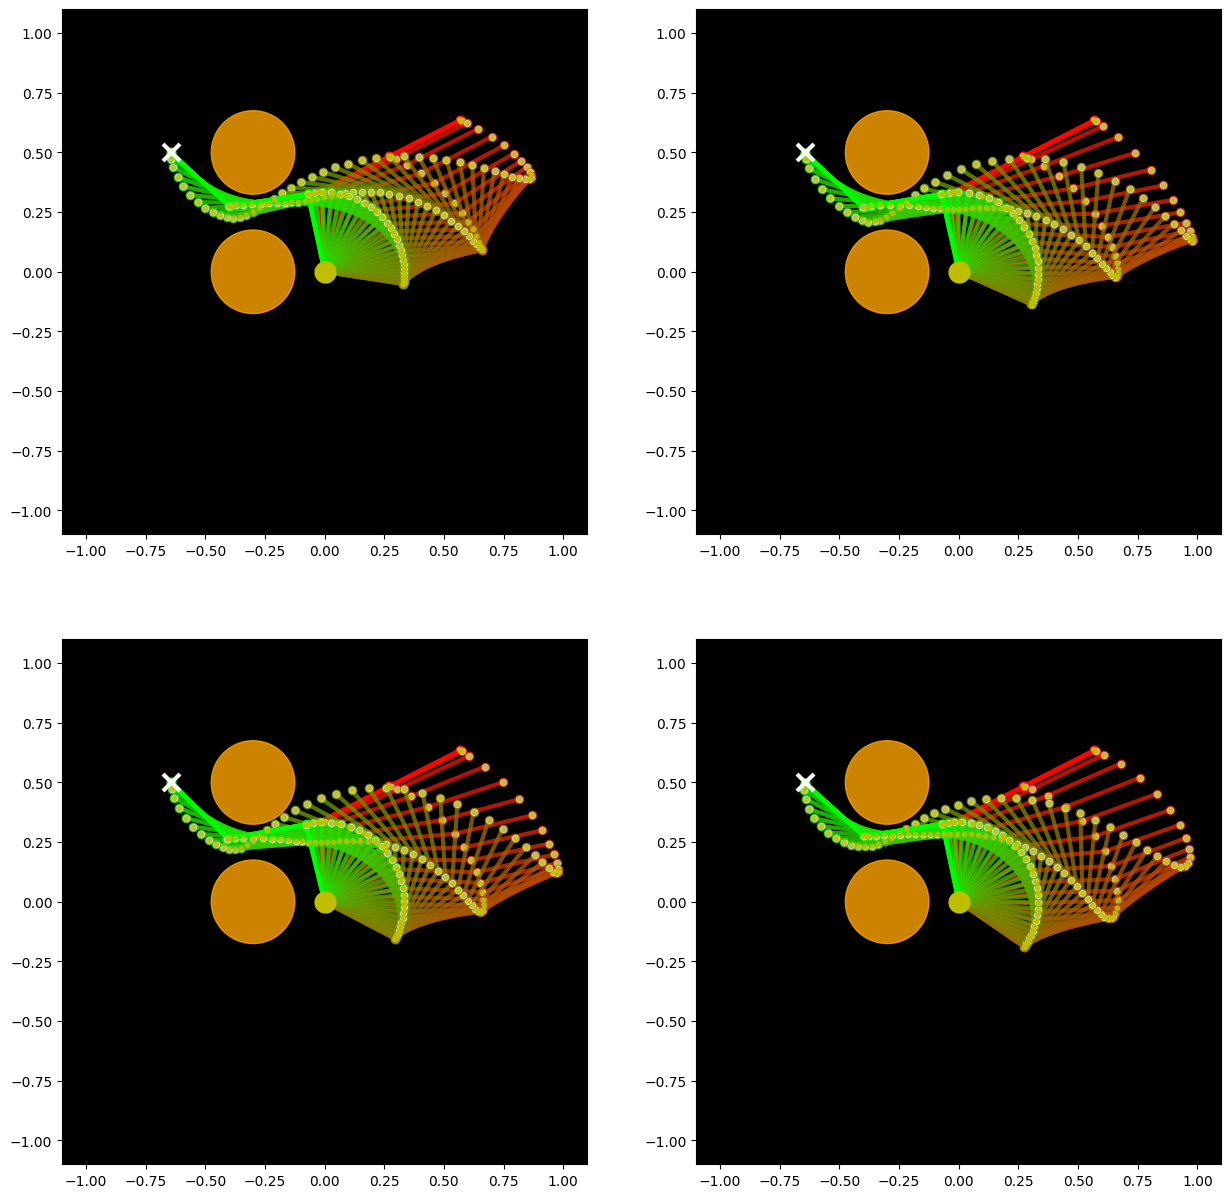

In [46]:

plot_traj(theta_t_2[:])